In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]  = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [11]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_transformers import BeautifulSoupTransformer
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

embd = OllamaEmbeddings(model="llama3:latest", base_url="http://localhost:11434")



urls = ["https://www.goal.com/en",
        "https://www.fourfourtwo.com/",
        "https://footballinsides.com/"
    ]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1000, chunk_overlap=100
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embd
)


retriever=vectorstore.as_retriever()

In [12]:
retriever.invoke("Current market news")

[Document(id='3c3ebc49-562b-46b1-8c36-4d96c0318806', metadata={'source': 'https://footballinsides.com/', 'title': 'Football Insides – Latest News, Tactical Analysis & More', 'description': 'Football Insides: blog with the latest news, match analysis, and tactical insights on Premier League, Champions League, and European football', 'language': 'en-US'}, page_content='August 2, 2025 \n\n\n\n\n\n\nHeung-Min Son Player Profile: From Bundesliga Talent to #1 LAFC Star \n\n\n\n\t\t\t\t\tAfter ten incredible years at Tottenham Hotspur, South Korean icon Heung-Min Son is set to make a sensational move to the Major League Soccer, joining LAFC. The transfer marks a new era for both the\t\t\t\t\n\n\n\n\n\n\nRead More\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nPlayer Profile \n\n\n\n\n\n\n\n\n \n\n\n\n\n\n\n\n\n\n \n\nJune 22, 2025 \n\n\n\n\n\n\nMohamed Salah Player Profile: From Egyptian Talent to Global Superstar \n\n\n\n\t\t\t\t\tMohamed Salah’s rise to the top of world football didn’t happen overn

### retrived finished

In [13]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""
    
    datasource: Literal["vectorstore", "websearch"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )

llm=ChatGroq(model="qwen/qwen3-32b")
structured_llm_router = llm.with_structured_output(RouteQuery)

system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to latest football news.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

# Testing
question = "Tottenham Hotspur"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(question_router.invoke({"document": doc_txt, "question": question}))
print("********************************")
question = "latest football news"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(question_router.invoke({"document": doc_txt, "question": question}))
print("********************************")
print(
    question_router.invoke(
        {"question": "Who won the football world cup 2026 "}
    )
)


datasource='vectorstore'
********************************
datasource='vectorstore'
********************************
datasource='websearch'


In [15]:
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

llm=ChatGroq(model="qwen/qwen3-32b")
structured_llm_grader = llm.with_structured_output(GradeDocuments)

system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved Document: \n\n {document} \n\n User Question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "latest football news"

docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"document": doc_txt, "question": question}))

question = "tasty food recipes"

docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"document": doc_txt, "question": question}))

binary_score='yes'
binary_score='no'


In [19]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

promt = hub.pull("rlm/rag-prompt")

llm=ChatGroq(model="qwen/qwen3-32b")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = promt | llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": "latest football news"})
print(generation)
print("******************************")
generation = rag_chain.invoke({"context": docs, "question":  "tasty food recipes"})
print(generation)

<think>
Okay, let's see. The user is asking for the latest football news. I need to use the provided context to answer. Let me check the documents.

First, from Goal.com, there's mention of transfers like Heung-Min Son moving to LAFC and some Hall of Fame features. But those might be older as the dates on FootballInsides are August and June 2025. Wait, the other FourFourTwo document has a date of 20 November 25, which seems to be the most recent. There's news about Gabriel Jesus possibly leaving Arsenal, Manchester United bidding for Tchouameni, and Cristiano Ronaldo at the White House. Also, a new Nike Barcelona shirt release. 

The user wants the latest, so the November 2025 articles are most relevant. Let me confirm the dates. The FootballInsides document has August 2025 and June 2025, while the other FourFourTwo has November 2025. So the latest news would be from November. 

So the key points are: Gabriel Jesus considering an exit from Arsenal, Manchester United's bid for Tchouamen

In [21]:
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm=ChatGroq(model="qwen/qwen3-32b")
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='yes')

In [22]:
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm=ChatGroq(model="qwen/qwen3-32b")
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [23]:
# LLM
llm=ChatGroq(model="qwen/qwen3-32b")

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'<think>\nOkay, the user just asked for "tasty food recipes." Let me think about how to improve that. First, the original query is pretty vague. "Tasty" is subjective, and "food recipes" is very broad. They might not get the best results from a vector store with such a general query.\n\nI need to make it more specific. Maybe they have a particular cuisine in mind, like Italian or Mexican. Also, considering dietary restrictions could be important—like vegetarian or gluten-free. Including a specific dish or ingredient might help narrow it down. For example, if they want Italian recipes, that\'s a good start. And maybe they\'re looking for quick weeknight meals instead of complicated ones. I should ask for clarification on cuisine, dietary needs, desired ingredients, meal type, and preparation time. That way, the search can be more precise and return better results.\n</think>\n\nCan you specify the type of cuisine (e.g., Italian, Mexican, Asian), dietary requirements (e.g., vegetarian, gl

In [24]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

In [25]:
from typing import List

from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [42]:
from langchain.schema import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)

    return {"documents": web_results, "question": question}


### Edges ###


def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    print("**************************")
    print(source.datasource)
    print("**************************")

    if source.datasource == "websearch":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

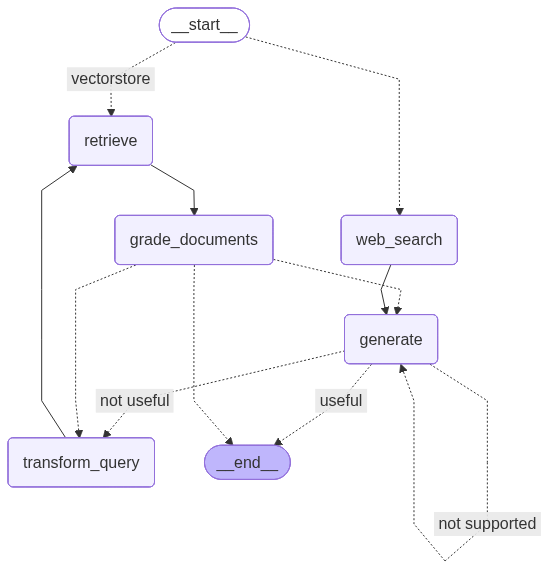

In [43]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [48]:
result=app.invoke({"question":"What is current football news?"})

final_answer = result["generation"]

print(final_answer)

---ROUTE QUESTION---
**************************
vectorstore
**************************
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
<think>
Okay, the user is asking for the current football news. Let me look at the provided context documents to find the latest updates.

First, checking the first document from FourFourTwo. The dates mentioned are November 25, 2020, but the user's current date is November 25, 2025, according to the second document. Wait, the first document has a date of "published 20 November 25" which might be a typo, maybe 2025? But the metadata might be different. The second d

In [47]:
result=app.invoke({"question":"Give me a good receipe?"})
final_answer = result["generation"]

print(final_answer)

---ROUTE QUESTION---
**************************
websearch
**************************
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
<think>
Okay, the user is asking for a good recipe. Let me look through the provided context to find a suitable one. There are several recipes mentioned here.

First, there's the Creamed Tacos recipe by Sheela Prakash. It mentions being a complete dinner on a sheet pan and suggests adding couscous, rice, or orzo. That sounds simple and easy. Another option is the Chickpea Caesar Salad with a Cheater’s Dressing by Katherine Gillen. It's vegetarian, beginner-friendly, and takes 45 minutes. The context also mentions a Taco Soup that's quick and uses pantry staples. 

The user might prefer something quick and easy. The Taco Soup has a total time of 40 minutes and uses simple ingredie

In [46]:
result = app.invoke({"question":"What is kjjih?"})
final_answer = result["generation"]

print(final_answer)

---ROUTE QUESTION---
**************************
websearch
**************************
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
<think>
Okay, so the user is asking about "kjjih," but there's a typo there. The correct term they probably meant is "Kijiji," as that's what's discussed in the context provided.

Looking at the context, Kijiji is a Canadian online classifieds site, similar to eBay or Craigslist. It's part of eBay's Classifieds Group and is popular in Canada. The Swahili word "kijiji" means village, which is where the name comes from. The user might be confused because of the typo, but the answer should clarify the correct spelling and the meaning behind it. Also, the context mentions it's used in over 100 Canadian cities and was launched in 2005. The Swahili origin part is important to explain t